In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

# Importation de ton module propriétaire
from backtest_engine import run_vectorized_backtest

# Style graphique épuré
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
# Téléchargement des données via l'API yfinance
ticker = "AAPL"
data = yf.download(ticker, start="2016-01-01", end="2026-01-01")

# Nettoyage pour s'assurer qu'on travaille avec des Series 1D propres
prices = data["Close"].squeeze()

print(f"Données récupérées pour {ticker} : {len(prices)} jours de trading.")
prices.head()

[*********************100%***********************]  1 of 1 completed

Données récupérées pour AAPL : 2514 jours de trading.


Date
2016-01-04    23.709103
2016-01-05    23.114965
2016-01-06    22.662619
2016-01-07    21.706150
2016-01-08    21.820932
Name: AAPL, dtype: float64

In [3]:
# 1. Calcul des indicateurs techniques
sma_short_window = 20
sma_long_window = 50

sma_short = prices.rolling(window=sma_short_window).mean()
sma_long = prices.rolling(window=sma_long_window).mean()

# 2. Génération des signaux vectorisés
# Signal = 1 (Achat) si SMA 20 > SMA 50, sinon 0 (Cash / Sortie du marché)
# REMARQUE QUANT : On pourrait mettre -1 pour une stratégie Short, mais le "Long-Only"
# est plus représentatif des contraintes réelles pour débuter.
signals = pd.Series(np.where(sma_short > sma_long, 1, 0), index=prices.index)

# On nettoie les premières lignes (NaN dues aux fenêtres de calcul des moyennes mobiles)
signals[:sma_long_window] = 0

# 3. Exécution du Backtest via notre moteur
results = run_vectorized_backtest(prices, signals)

# Affichage des métriques clés
print("=" * 40)
print(f"📊 PERFORMANCE REPORT FOR {ticker} (SMA {sma_short_window}/{sma_long_window})")
print("=" * 40)
print(f"Strat Return        : {results['total_return'] * 100:.2f}%")
print(f"Annualized Return   : {results['annualized_return'] * 100:.2f}%")
print(f"Annualized Vol      : {results['annualized_volatility'] * 100:.2f}%")
print(f"Sharpe Ratio        : {results['sharpe_ratio']:.2f}")
print(f"Max Drawdown        : {results['max_drawdown'] * 100:.2f}%")
print("=" * 40)

📊 PERFORMANCE REPORT FOR AAPL (SMA 20/50)
Strat Return        : 306.49%
Annualized Return   : 15.10%
Annualized Vol      : 20.13%
Sharpe Ratio        : 0.75
Max Drawdown        : -29.09%


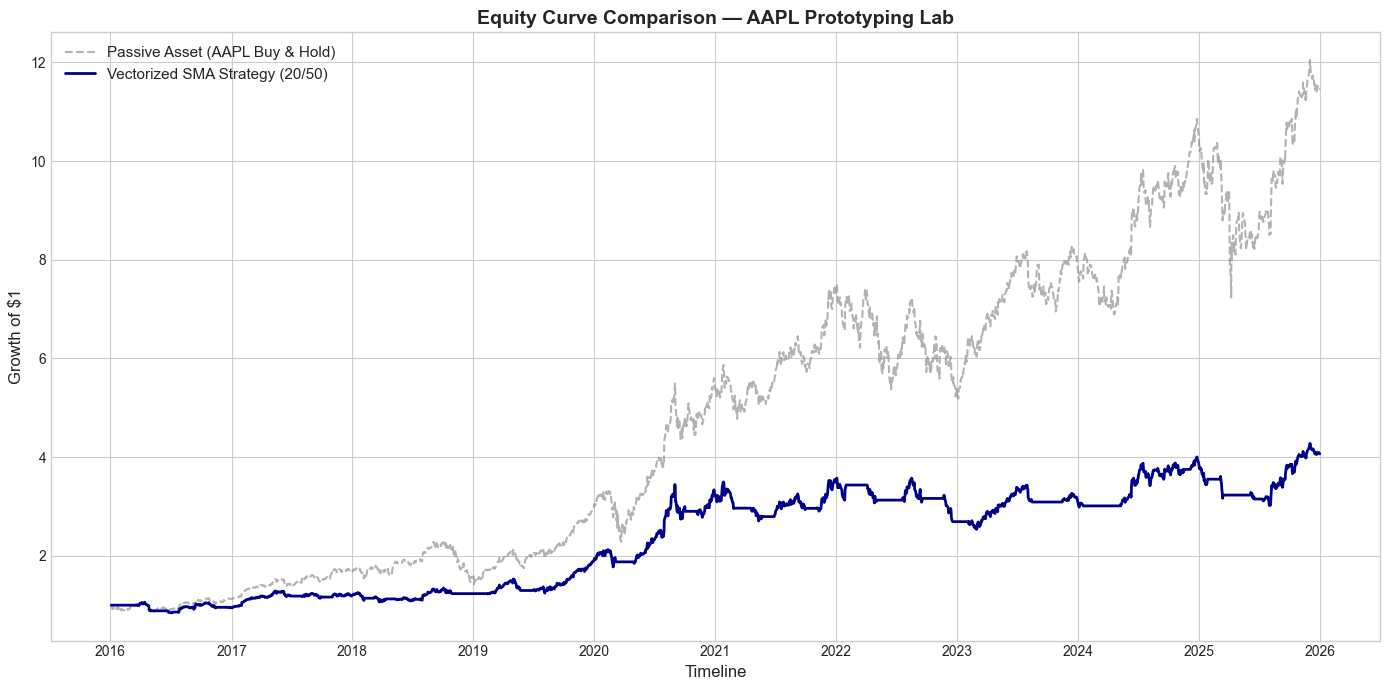

In [4]:
# Génération du graphique comparatif des courbes de capital
plt.figure(figsize=(14, 7))

plt.plot(
    results["asset_equity"],
    label=f"Passive Asset ({ticker} Buy & Hold)",
    color="gray",
    alpha=0.6,
    linestyle="--",
)
plt.plot(
    results["strategy_equity"],
    label=f"Vectorized SMA Strategy ({sma_short_window}/{sma_long_window})",
    color="darkblue",
    linewidth=2,
)

plt.title(
    f"Equity Curve Comparison — {ticker} Prototyping Lab",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Timeline", fontsize=12)
plt.ylabel("Growth of $1", fontsize=12)
plt.legend(fontsize=11, loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
" Remarques "

# 1. Biais d'Exécution Dompté : 
# --> shift(1) garantit le strict respect de la barrière temporelle 
# --> le signal calculé avec les cours de clôture du jour t n'est appliqué que sur le rendement du jour t+1 


# 2. Le Mythe des Coûts Zéro : 
# --> Ce backtest vectorisé est un prototype de premier niveau dits "frictionless". 
# --> En conditions réelles, l'impact des commissions de courtage et du *slippage* (écart de prix à l'exécution) réduirait le Ratio de Sharpe. 
# --> La prochaine étape industrielle consistera à injecter un coût fixe à chaque changement d'état du vecteur `signals`.


# 3. Annualisation & Volatilité : 
# --> L'ajustement par sqrt{252} repose sur l'hypothèse sous-jacente que les rendements quotidiens sont identiquement et indépendamment distribués (i.i.d.). 
# --> Bien que imparfaite en finance (phénomène de volatility clustering), cette normalisation reste le standard institutionnel pour benchmarker deux stratégies.